In [1]:
device = "cuda"
model_ckpt = "meta-llama/Llama-3.2-1B"

In [2]:
# Parameters
model_ckpt = "meta-llama/Llama-3.1-8B"


### Preliminaries

In [3]:
import itertools
import random
import collections

import transformers
import torch
import tqdm.auto
import plotly.express
import plotly.graph_objects
import sklearn.decomposition
import matplotlib
import PIL.Image
import numpy as np
from torch import Tensor

In [4]:
def sinusoidal_encode(
    x: Tensor,
    embedding_dim: int,
    min_value: int,
    max_value: int,
    use_l2_norm: bool = False,
    norm_const: float | None = None,
) -> Tensor:
    """
    Encodes a tensor of numbers into a sinusoidal representation, inspired by how absolute positional
    encoding works in transformers.

    The encoding is an evaluation of a sine and cosine function at different frequencies, where the
    frequency is determined by the embedding dimension and the allowed range of the input values.

    >>> sinusoidal_encode(
    ...     torch.tensor([-5, 2, 1, 0]),
    ...     embedding_dim=6,
    ...     min_value=-5,
    ...     max_value=5,
    ... )
    tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
            [ 0.6570,  0.7539, -0.1073, -0.9942,  0.9980,  0.0627],
            [-0.2794,  0.9602,  0.3491, -0.9371,  0.9616,  0.2746],
            [-0.9589,  0.2837,  0.7317, -0.6816,  0.8806,  0.4738]])
    """

    if embedding_dim % 2 != 0 and not use_l2_norm:
        raise ValueError("Embedding dimension must be even")

    if use_l2_norm:
        if embedding_dim % 2 == 0:
            reserved_dim = 2
        else:
            reserved_dim = 1
        embedding_dim -= reserved_dim
    else:
        reserved_dim = 0  # will not be used

    domain = max_value - min_value
    y_shape = x.shape + (embedding_dim,)
    y = torch.zeros(y_shape, device=x.device)
    even_indices = torch.arange(0, embedding_dim, 2)
    log_term = torch.log(torch.tensor(domain)) / embedding_dim
    div_term = torch.exp(even_indices * -log_term)
    x = x - min_value
    values = x.unsqueeze(-1).float() * div_term
    y[..., 0::2] = torch.sin(values)
    y[..., 1::2] = torch.cos(values)

    if use_l2_norm:
        y = torch.cat([y, torch.ones_like(y[..., :reserved_dim])], dim=-1)
        y /= y.norm(dim=-1, keepdim=True, p=2)

    if norm_const is not None:
        y *= norm_const

    return y

def binary_encode(
    x: Tensor,
    embedding_dim: int,
    min_value: int | float,
    max_value: int | float,
    use_l2_norm: bool = False,
    norm_const: float | None = None,
) -> Tensor:
    y = torch.zeros(x.shape + (embedding_dim,), device=x.device)
    reserve_dim = 0 if not use_l2_norm else 1
    x = x - min_value
    maximum = x.max()
    for i in range(embedding_dim - reserve_dim):
        coeff = 2**i
        if maximum < coeff:
            break
        y[..., -i - 1] = torch.floor(x / coeff) % 2
        x = x - coeff * y[..., -i - 1]
    if use_l2_norm:
        y = torch.cat([y, torch.ones_like(y[..., :reserve_dim])], dim=-1)
        y /= y.norm(dim=-1, keepdim=True, p=2)
    if norm_const is not None:
        y *= norm_const
    return y

### Prepare model and data

In [5]:
model = transformers.AutoModel.from_pretrained(model_ckpt).eval()
tokenizer = transformers.AutoTokenizer.from_pretrained(model_ckpt)
model = model.half().to(device).eval()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [6]:
all_values = torch.arange(0, 1000)
mask = torch.rand(len(all_values), generator=torch.Generator().manual_seed(0))
train_mask = mask < 0.9
valid_mask = ~train_mask & (mask < 0.95)
test_mask = ~train_mask & ~valid_mask

train_values = all_values[train_mask]
valid_values = all_values[valid_mask]
test_values = all_values[test_mask]

In [7]:
all_inputs = [(x1, x2) for x1, x2 in itertools.product(all_values.tolist(), repeat=2) if x1 + x2 < 1000]
train_values_set = set(train_values.tolist())
valid_values_set = set(valid_values.tolist())
test_values_set = set(test_values.tolist())
        
train_inputs = [(x1, x2) for x1, x2 in all_inputs if x2 in train_values_set]
valid_inputs = [(x1, x2) for x1, x2 in all_inputs if x2 in valid_values_set]
test_inputs = [(x1, x2) for x1, x2 in all_inputs if x2 in test_values_set]

# sanity check
assert set(train_inputs) & set(valid_inputs) == set()
assert set(train_inputs) & set(test_inputs) == set()
assert set(valid_inputs) & set(test_inputs) == set()

rng_py = random.Random(0)
rng_py.shuffle(train_inputs)
rng_py.shuffle(valid_inputs)
rng_py.shuffle(test_inputs)
valid_size = 4096
train_size = 100_000
train_inputs = train_inputs[:train_size]
valid_inputs = valid_inputs[:valid_size]

In [8]:
def make_str_input(operands: tuple[int, int] | list[int]) -> str:
    x1, x2 = operands
    return f"{x1} + {x2}"

make_str_input((3, 500)), make_str_input((3, 0))

('3 + 500', '3 + 0')

In [9]:
def get_hidden_states(model, str_inputs: list[str], batch_size: int) -> collections.defaultdict[int, Tensor]:
    model.eval()
    hidden_states = collections.defaultdict(list)
    with torch.no_grad():
        num_batches = (len(str_inputs) + batch_size - 1) // batch_size
        for batch_str in tqdm.auto.tqdm(itertools.batched(str_inputs, n=batch_size), total=num_batches):
            batch_inputs = tokenizer(batch_str, return_tensors="pt")
            hidden_reprs = model(**batch_inputs.to(model.device), output_hidden_states=True).hidden_states
            for layer_idx, hidden_state in enumerate(hidden_reprs):
                hidden_states[layer_idx].extend(hidden_state[:, -1, :].detach().cpu())
    return {k: torch.stack(v) for k, v in hidden_states.items()}

In [10]:
batch_size = 1024
train_hidden_states = get_hidden_states(model, [make_str_input(val) for val in train_inputs], batch_size)
valid_hidden_states = get_hidden_states(model, [make_str_input(val) for val in valid_inputs], batch_size)
test_hidden_states = get_hidden_states(model, [make_str_input(val) for val in test_inputs], batch_size)

train_labels = torch.tensor([x2 for x1, x2 in train_inputs])
valid_labels = torch.tensor([x2 for x1, x2 in valid_inputs]).to(device)
test_labels = torch.tensor([x2 for x1, x2 in test_inputs]).to(device) 

  0%|          | 0/98 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

### Probe definition

In [11]:
basis_embs_sin = sinusoidal_encode(
    torch.arange(1000),
    min_value=0,
    max_value=1000,
    embedding_dim=train_hidden_states[0].shape[-1],
)

In [12]:
class ClassifierProbe(torch.nn.Module):
    def __init__(self, emb_dim: int, hidden_dim: int, basis: torch.Tensor, heldout_mask: torch.Tensor):
        super().__init__()
        self.emb_to_latent = torch.nn.Linear(emb_dim, hidden_dim, bias=True)
        self.basis_to_latent = torch.nn.Linear(basis.shape[-1], hidden_dim, bias=True)
        self.basis: torch.nn.Buffer
        self.heldout_mask: torch.nn.Buffer
        self.register_buffer("basis", basis)
        self.register_buffer("heldout_mask", heldout_mask)
        
    def forward(self, x: Tensor, holdout_eval_tokens: bool) -> Tensor:
        latent_x = self.emb_to_latent(x)
        # during training, model learns to choose among only training tokens
        # but during eval, model must choose among all tokens
        # this means that the model is never exposed to the eval tokens during training
        latent_choices = self.basis_to_latent(self.basis)
        logits = latent_x @ latent_choices.T
        if holdout_eval_tokens:
            logits[:, self.heldout_mask] = float("-inf")
        return logits

### L1-regularized probes and evaluation of cross-layer transfer

In [13]:
probes_l1 = {}

histories_l1 = []
for layer_idx in range(0, len(train_hidden_states)):

    torch.manual_seed(0)
    probe = ClassifierProbe(
        emb_dim=train_hidden_states[0].shape[-1],
        hidden_dim=100,
        basis=basis_embs_sin,
        heldout_mask=test_mask,
    ).to(device)

    optimizer = torch.optim.Adam(probe.parameters(), lr=1e-4, weight_decay=0)

    rng = torch.Generator().manual_seed(0)
    best_val_acc = -1
    best_ckpt = None
    for step in range(10000+1):
        probe.train()
        optimizer.zero_grad()
        minibatch_idcs = torch.randint(len(train_labels), size=(1024,), generator=rng)
        x = train_hidden_states[layer_idx][minibatch_idcs].float().to(device)
        y = train_labels[minibatch_idcs].to(device)
        train_logits = probe(x, holdout_eval_tokens=True)
        loss = torch.nn.functional.cross_entropy(train_logits, y)
        loss += 1e-3 * sum(p.abs().sum() for p in probe.parameters()) # L1 regularization
        loss.backward()
        optimizer.step()

        if step % 1000 == 0:
            train_acc = (train_logits.argmax(dim=-1) == y).float().mean().item()
            probe.eval()
            with torch.no_grad():
                valid_logits = probe(valid_hidden_states[layer_idx].float().to(device), holdout_eval_tokens=False)
                valid_loss = torch.nn.functional.cross_entropy(valid_logits, valid_labels)
                valid_acc = (valid_logits.argmax(dim=-1) == valid_labels).float().mean().item()
                if valid_acc > best_val_acc:
                    best_val_acc = valid_acc
                    best_ckpt = probe.state_dict()
            entry = {"layer": layer_idx, "step": step, "train_loss": loss.item(), "train_acc": train_acc, "valid_loss": valid_loss.item(), "valid_acc": valid_acc}
            histories_l1.append(entry)
            print(f"{layer_idx=:<3}  {step=:<7}  {loss=:<7.2f}  {train_acc=:<8.2%}  {valid_loss=:<7.2f}  {valid_acc=:<7.2%}")
    print()
    probe.load_state_dict(best_ckpt)
    probes_l1[layer_idx] = probe


layer_idx=0    step=0        loss=13.26    train_acc=0.00%     valid_loss=6.88     valid_acc=0.00%  


layer_idx=0    step=1000     loss=3.96     train_acc=26.66%    valid_loss=3.31     valid_acc=0.00%  


layer_idx=0    step=2000     loss=3.40     train_acc=50.39%    valid_loss=2.78     valid_acc=11.67% 


layer_idx=0    step=3000     loss=3.05     train_acc=71.78%    valid_loss=2.46     valid_acc=18.26% 


layer_idx=0    step=4000     loss=2.79     train_acc=85.45%    valid_loss=2.23     valid_acc=30.40% 


...

layer_idx=32   step=6000     loss=0.52     train_acc=99.90%    valid_loss=0.18     valid_acc=98.95% 


layer_idx=32   step=7000     loss=0.48     train_acc=99.80%    valid_loss=0.17     valid_acc=98.68% 


layer_idx=32   step=8000     loss=0.46     train_acc=99.61%    valid_loss=0.15     valid_acc=98.95% 


layer_idx=32   step=9000     loss=0.43     train_acc=99.71%    valid_loss=0.14     valid_acc=98.88% 


layer_idx=32   step=10000    loss=0.41     train_acc=99.80%    valid_loss=0.12     valid_acc=99.00% 



In [14]:
test_accuracies_l1 = torch.zeros((len(probes_l1), len(test_hidden_states))) - float("nan")
for probe_idx, probe in enumerate(probes_l1.values()):
    probe.eval()
    for layer_idx in range(len(test_hidden_states)):
        with torch.no_grad():
            test_logits = probe(test_hidden_states[layer_idx].float().to(device), holdout_eval_tokens=False)
            test_accuracy = (test_logits.argmax(dim=-1) == test_labels).float().mean().item()
        test_accuracies_l1[probe_idx, layer_idx] = test_accuracy

plotly.express.imshow(
    test_accuracies_l1,
    labels={"y": "Layer fit idx", "x": "Layer eval idx", "color": "Test accuracy"},
    color_continuous_scale="Reds"
).update_layout(
    yaxis=dict(tickvals=list(range(len(probes_l1))), ticktext=list(probes_l1.keys()))
)

### L2-regularized probes and evalution of cross-layer transfer

In [15]:
probes_l2 = {}

histories_l2 = []
for layer_idx in range(0, len(train_hidden_states)):

    torch.manual_seed(0)
    probe = ClassifierProbe(
        emb_dim=train_hidden_states[0].shape[-1],
        hidden_dim=100,
        basis=basis_embs_sin,
        heldout_mask=test_mask,
    ).to(device)

    optimizer = torch.optim.Adam(probe.parameters(), lr=1e-4, weight_decay=1e-3)

    rng = torch.Generator().manual_seed(0)
    best_val_acc = -1
    best_ckpt = None
    for step in range(10000+1):
        probe.train()
        optimizer.zero_grad()
        minibatch_idcs = torch.randint(len(train_labels), size=(1024,), generator=rng)
        x = train_hidden_states[layer_idx][minibatch_idcs].float().to(device)
        y = train_labels[minibatch_idcs].to(device)
        train_logits = probe(x, holdout_eval_tokens=True)
        loss = torch.nn.functional.cross_entropy(train_logits, y)
        loss.backward()
        optimizer.step()

        if step % 1000 == 0:
            train_acc = (train_logits.argmax(dim=-1) == y).float().mean().item()
            probe.eval()
            with torch.no_grad():
                valid_logits = probe(valid_hidden_states[layer_idx].float().to(device), holdout_eval_tokens=False)
                valid_loss = torch.nn.functional.cross_entropy(valid_logits, valid_labels)
                valid_acc = (valid_logits.argmax(dim=-1) == valid_labels).float().mean().item()
                if valid_acc > best_val_acc:
                    best_val_acc = valid_acc
                    best_ckpt = probe.state_dict()
            entry = {"layer": layer_idx, "step": step, "train_loss": loss.item(), "train_acc": train_acc, "valid_loss": valid_loss.item(), "valid_acc": valid_acc}
            histories_l2.append(entry)
            print(f"{layer_idx=:<3}  {step=:<7}  {loss=:<7.2f}  {train_acc=:<8.2%}  {valid_loss=:<7.2f}  {valid_acc=:<7.2%}")
    print()
    probe.load_state_dict(best_ckpt)
    probes_l2[layer_idx] = probe


layer_idx=0    step=0        loss=6.86     train_acc=0.00%     valid_loss=6.87     valid_acc=0.00%  


layer_idx=0    step=1000     loss=0.49     train_acc=99.51%    valid_loss=1.71     valid_acc=39.62% 


layer_idx=0    step=2000     loss=0.20     train_acc=100.00%   valid_loss=1.85     valid_acc=46.19% 


layer_idx=0    step=3000     loss=0.14     train_acc=100.00%   valid_loss=1.97     valid_acc=53.66% 


layer_idx=0    step=4000     loss=0.11     train_acc=100.00%   valid_loss=1.88     valid_acc=53.47% 


...

layer_idx=32   step=6000     loss=0.00     train_acc=100.00%   valid_loss=1.42     valid_acc=76.07% 


layer_idx=32   step=7000     loss=0.01     train_acc=99.80%    valid_loss=1.05     valid_acc=77.64% 


layer_idx=32   step=8000     loss=0.00     train_acc=100.00%   valid_loss=0.81     valid_acc=79.52% 


layer_idx=32   step=9000     loss=0.00     train_acc=100.00%   valid_loss=0.75     valid_acc=80.57% 


layer_idx=32   step=10000    loss=0.00     train_acc=100.00%   valid_loss=0.70     valid_acc=81.35% 



In [16]:
test_accuracies_l2 = torch.zeros((len(probes_l2), len(test_hidden_states))) - float("nan")
for probe_idx, probe in enumerate(probes_l2.values()):
    probe.eval()
    for layer_idx in range(len(test_hidden_states)):
        with torch.no_grad():
            test_logits = probe(test_hidden_states[layer_idx].float().to(device), holdout_eval_tokens=False)
            test_accuracy = (test_logits.argmax(dim=-1) == test_labels).float().mean().item()
        test_accuracies_l2[probe_idx, layer_idx] = test_accuracy

plotly.express.imshow(
    test_accuracies_l2,
    labels={"y": "Layer fit idx", "x": "Layer eval idx", "color": "Test accuracy"},
    color_continuous_scale="Reds"
).update_layout(
    yaxis=dict(tickvals=list(range(len(probes_l2))), ticktext=list(probes_l2.keys()))
)

### Held-one-out cross-layer transfer

In [17]:
rng = torch.Generator().manual_seed(0)
rng_py = random.Random(0)

assert list(train_hidden_states.keys()) == list(range(len(train_hidden_states)))
train_hidden_states_tensor = torch.stack(list(train_hidden_states.values()), dim=0)

heldoneout_probes = {}
heldoneout_histories = []

for heldout_layer_idx in range(len(train_hidden_states)):

    torch.manual_seed(0)
    probe = ClassifierProbe(
        emb_dim=train_hidden_states[0].shape[-1],
        hidden_dim=100,
        basis=basis_embs_sin,
        heldout_mask=test_mask,
    ).to(device)

    optimizer = torch.optim.Adam(probe.parameters(), lr=1e-4, weight_decay=0)

    train_layers = [i for i in range(len(train_hidden_states)) if i != heldout_layer_idx]

    print("HELDOUT LAYER:", heldout_layer_idx)
    for step in range(10000+1):
        probe.train()
        optimizer.zero_grad()
        layer_idcs = torch.tensor(rng_py.choices(train_layers, k=1024))
        minibatch_idcs = torch.randint(len(train_labels), size=(1024,), generator=rng)
        x = train_hidden_states_tensor[layer_idcs, minibatch_idcs].float().to(device)
        y = train_labels[minibatch_idcs].to(device)
        train_logits = probe(x, holdout_eval_tokens=True)
        loss = torch.nn.functional.cross_entropy(train_logits, y)
        loss += 1e-3 * sum(p.abs().sum() for p in probe.parameters()) # L1 regularization
        loss.backward()
        optimizer.step()

        best_val_acc = -1
        best_ckpt = probe.state_dict()

        if step % 1000 == 0:
            probe.eval()
            valid_accs = []
            with torch.no_grad():
                print(f"{step=:<5}", end="  ")
                for layer_idx in range(0, len(train_hidden_states)):
                    valid_logits = probe(valid_hidden_states[layer_idx].float().to(device), holdout_eval_tokens=False)
                    valid_acc = (valid_logits.argmax(dim=-1) == valid_labels).float().mean().item()
                    valid_accs.append(valid_acc)
                    heldoneout_histories.append({"heldout_layer": heldout_layer_idx, "step": step, "eval_layer": layer_idx, "valid_acc": valid_acc})
                    acc_out = f"{valid_acc:>6.1%}"
                    if layer_idx not in train_layers:
                        print('\033[94m' + acc_out + '\033[0m', end=" ")
                    else:
                        print(acc_out, end=" ")
                print()
                if valid_accs[heldout_layer_idx] > best_val_acc:
                    best_val_acc = valid_accs[heldout_layer_idx]
                    best_ckpt = probe.state_dict()

        probe.load_state_dict(best_ckpt)
        heldoneout_probes[heldout_layer_idx] = probe


HELDOUT LAYER: 0
step=0        0.0%   0.0%   0.6%   0.1%   0.0%   0.0%   0.3%   0.1%   0.4%   0.0% 

  0.2%   0.0%   0.1%   0.0%   0.1%   0.0%   0.2%   1.1%   0.0%   0.1%   0.0% 

  0.0%   0.7%   1.2%   0.3%   0.0%   1.1%   1.0%   0.0%   0.1%   0.0%   0.0%   0.0% 


step=1000     3.4%  73.5%  77.8%  78.5%  88.8%  93.8%  93.9%  95.0%  95.8%  96.6%  94.2%  95.7% 

 95.7%  95.8%  99.5%  97.0%  99.3%  99.6%  99.3%  99.2%  99.8%  99.9%  99.9%  99.5% 

...

 99.0%  98.5%  99.7%  99.6%  99.2%  97.6%  96.9%  99.4%  99.7%  99.6%  99.4%  99.1%  98.6% 

 99.4%  99.0%  99.3%  99.3%  99.0%  98.4%  98.1%   0.1% 


step=10000   39.0%  93.1%  89.4%  92.9%  96.7%  98.7%  99.1%  99.0%  98.3%  98.9%  99.4%  98.6% 

 99.0%  98.3%  99.5%  99.5%  98.9%  97.3%  96.5%  98.8%  99.5%  99.3%  99.3%  98.3%  98.0% 

 99.2%  98.7%  99.0%  99.1%  98.6%  98.4%  98.1%   0.1% 


In [18]:
heldoneout_test_accs = torch.zeros(len(heldoneout_probes)) - float("nan")
for heldout_layer_idx, probe in heldoneout_probes.items():
    probe.eval()
    with torch.no_grad():
        test_logits = probe(test_hidden_states[heldout_layer_idx].float().to(device), holdout_eval_tokens=False)
        test_accuracy = (test_logits.argmax(dim=-1) == test_labels).float().mean().item()
        heldoneout_test_accs[heldout_layer_idx] = test_accuracy

plotly.express.bar(
    x=list(heldoneout_probes.keys()),
    y=heldoneout_test_accs.numpy(),
    labels={"x": "Heldout layer idx", "y": "Test accuracy"},
    title="Heldout Layer Probe Test Accuracies",
)

### Select layers for further visualization

In [19]:
# take first 3, last 3 and middle 3 from sorted(probes_l1.keys())
layer_idcs_to_plot = sorted(probes_l1.keys())
layer_idcs_to_plot = layer_idcs_to_plot[:3] + layer_idcs_to_plot[len(layer_idcs_to_plot)//2-2:len(layer_idcs_to_plot)//2+1] + layer_idcs_to_plot[-3:]
layer_idcs_to_plot = sorted(set(layer_idcs_to_plot))
layer_idcs_to_plot

[0, 1, 2, 14, 15, 16, 30, 31, 32]

### Visualizations of fourier of activations' PCA in various layers

In [20]:
def pca(embs: Tensor, low_dim: int) -> tuple[Tensor, Tensor]:
    pca = sklearn.decomposition.PCA(n_components=low_dim)
    reduced_embs = pca.fit_transform(embs.detach().numpy())
    return torch.tensor(reduced_embs), torch.tensor(pca.explained_variance_ratio_)

def fourier(embs: Tensor) -> Tensor:
    return torch.fft.fft(embs, dim=0)

In [21]:
all_values = torch.arange(0, 1000)
inputs = tokenizer([str(x) for x in all_values.tolist()], return_tensors="pt")
all_representations = torch.stack(model(**inputs.to(device), output_hidden_states=True).hidden_states)
all_representations = all_representations[:, :, -1, :] # get the last token (remove BOS)
all_representations.shape

torch.Size([33, 1000, 4096])

In [22]:
layer_ffts = []
for layer_idx in range(len(all_representations)):
    representations = all_representations[layer_idx].cpu()
    repr_pca, explained_var = pca(representations.float(), low_dim=100)
    repr_fft = fourier(repr_pca).abs().T.sum(dim=0)
    layer_ffts.append(repr_fft)

layer_ffts = torch.stack(layer_ffts)
fft_correlations = torch.corrcoef(layer_ffts)

plotly.express.imshow(
    # correlations (similarity) between layers' Fourier spectra
    fft_correlations,
    zmin=0,
    zmax=1,
)

In [23]:
for layer_idx in layer_idcs_to_plot:
    representations = all_representations[layer_idx].cpu()
    repr_pca, explained_var = pca(representations.float(), low_dim=100)
    repr_fft = fourier(repr_pca)
    
    plotly.express.bar(
        torch.abs(repr_fft).T.sum(dim=0).cpu().detach(),
    ).update_layout(title=f"Layer {layer_idx} PCA Fourier Frequencies", showlegend=False).update_xaxes(title="Frequency").show()

    # plotly.express.imshow(
    #     torch.abs(repr_fft).T.cpu().detach(),
    #     color_continuous_scale="Reds",
    #     aspect='auto',
    # ).update_layout(title=f"Layer {layer_idx} PCA Fourier Frequency Heatmap").update_xaxes(title="Frequency").update_yaxes(title="Feature").show()

### Visualization of probe sparsity (features' scatteredness)

In [24]:
usages = []
for constant in [1e-1, 1e-2, 1e-3, 1e-4]:
    usages.append([])
    for layer_idx in range(len(probes_l1)):
        probe = probes_l1[layer_idx]
        feature_usage = (probe.emb_to_latent.weight.abs() > constant).any(dim=0).float().mean().item()
        usages[-1].append(feature_usage)
usages = torch.tensor(usages)
usages = usages.diff(dim=0, prepend=torch.zeros((1, usages.shape[1])))

plotly.express.bar(
    x=list(probes_l1.keys()),
    y=usages.tolist().copy(),
    # make a stacked bar chart with darkest color at the bottom, pick predefined colors
    color_discrete_sequence=plotly.colors.sequential.Blues[5::-1],
).update_layout(title="How many features are used by the probe").update_xaxes(title="Layer idx").show()

Layer 0 Probe's Weights:


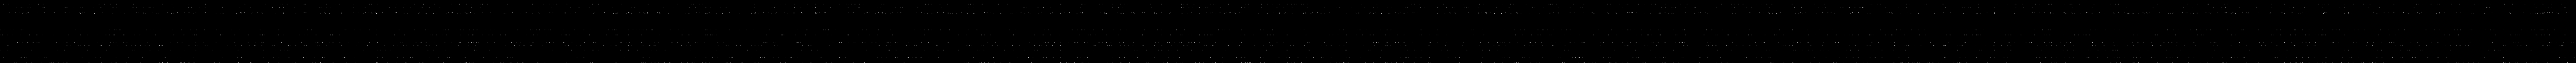

Layer 1 Probe's Weights:


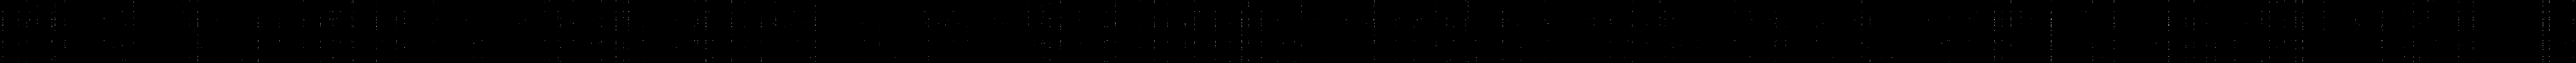

Layer 2 Probe's Weights:


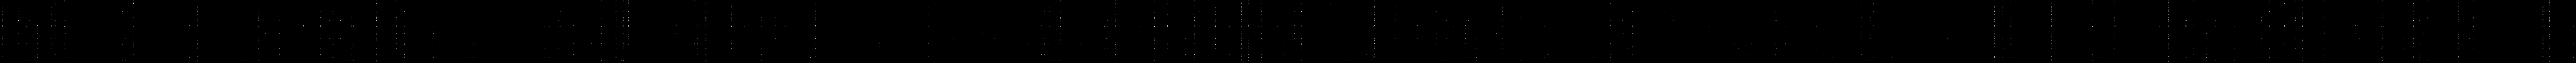

Layer 14 Probe's Weights:


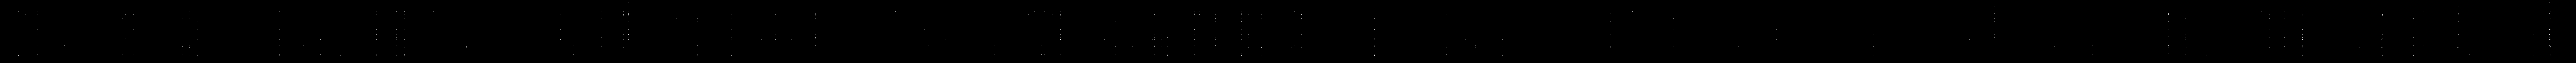

Layer 15 Probe's Weights:


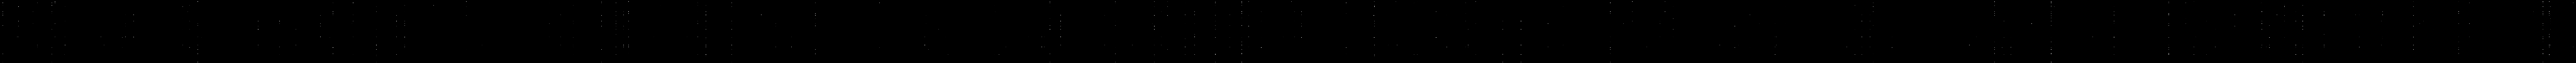

Layer 16 Probe's Weights:


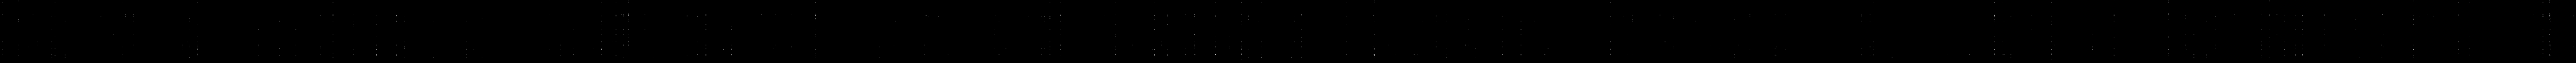

Layer 30 Probe's Weights:


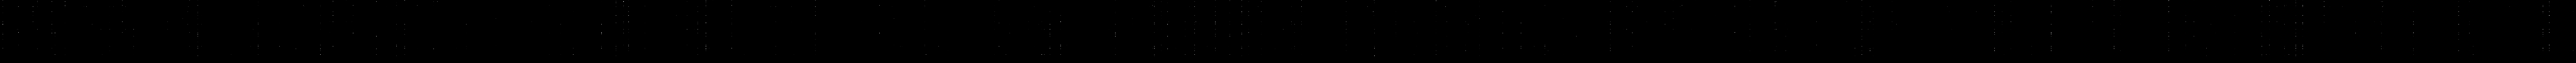

Layer 31 Probe's Weights:


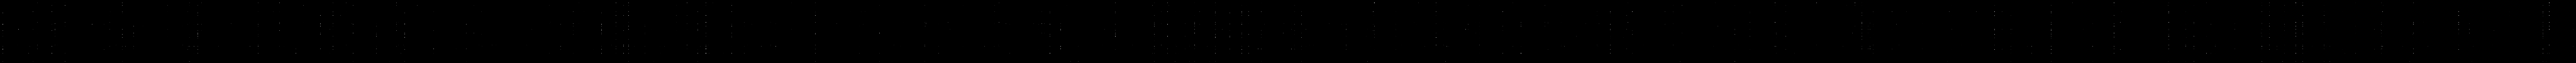

Layer 32 Probe's Weights:


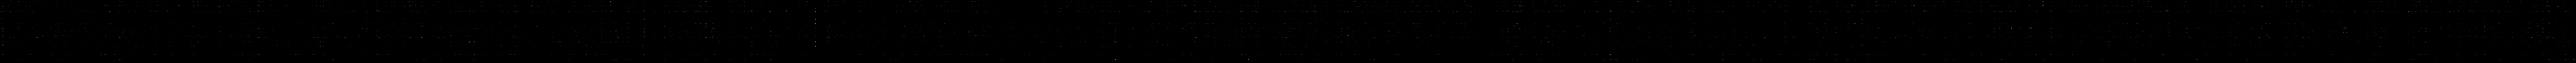

In [25]:
for layer_idx in layer_idcs_to_plot:
    probe = probes_l1[layer_idx]
    x: Tensor = probe.emb_to_latent.weight.cpu().detach().abs()
    x_normalized = (x - x.min()) / (x.max() - x.min())
    vis = PIL.Image.fromarray((x_normalized * 255).byte().numpy())
    print(f"Layer {layer_idx} Probe's Weights:", flush=True)
    display(vis)